# 07 Sales Forecasting with Linear Regression

## Objective
Predict pharmacy revenue using notebook-native code only.

## Approach
- Prepare features from sales transactions
- Build Linear Regression with one-hot encoding
- Evaluate with RMSE and R2
- Save trained model

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

candidate_roots = [Path.cwd(), Path.cwd().parent]
project_root = next((p for p in candidate_roots if (p / 'data').exists()), None)
if project_root is None:
    raise FileNotFoundError('Could not locate data folder. Run from project root or notebooks folder.')

data_dir = project_root / 'data'
models_dir = project_root / 'models'
models_dir.mkdir(parents=True, exist_ok=True)

print(f'Project Root: {project_root}')
print(f'Data Directory: {data_dir}')

Project Root: D:\projects\ai-ml-projects\PharmaEase_correct\pharma_ease_ai
Data Directory: D:\projects\ai-ml-projects\PharmaEase_correct\pharma_ease_ai\data


In [2]:
sales = pd.read_csv(data_dir / 'sales.csv')

sales['date'] = pd.to_datetime(sales['date'], errors='coerce')
sales['day_of_week'] = sales['date'].dt.dayofweek
sales['month'] = sales['date'].dt.month
sales['revenue'] = sales['quantity'] * sales['price']

X = sales[['items', 'quantity', 'price', 'day_of_week', 'month']]
y = sales['revenue']

print(f'Sales dataset shape: {sales.shape}')
print(f'Total revenue: ${sales["revenue"].sum():,.2f}')

Sales dataset shape: (2000, 9)
Total revenue: $720,424.30


In [3]:
categorical_cols = ['items']
numeric_cols = ['quantity', 'price', 'day_of_week', 'month']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols),
    ]
)

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression()),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
r2 = float(r2_score(y_test, y_pred))

print('Model Evaluation:')
print(f'  RMSE: ${rmse:.2f}')
print(f'  R2: {r2:.4f}')
print(f'  Test samples: {len(X_test)}')

Model Evaluation:
  RMSE: $108.73
  R2: 0.8689
  Test samples: 400


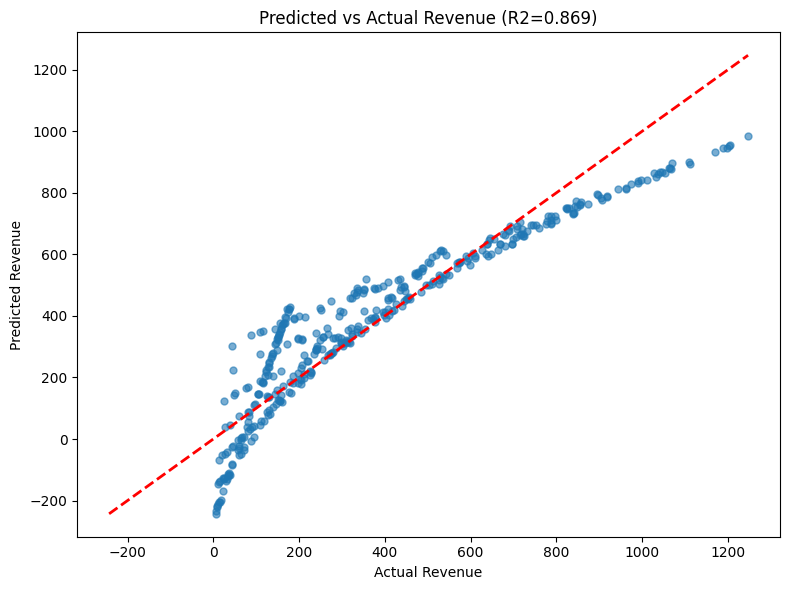

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, s=25)
line_min = min(y_test.min(), y_pred.min())
line_max = max(y_test.max(), y_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], 'r--', linewidth=2)
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.title(f'Predicted vs Actual Revenue (R2={r2:.3f})')
plt.tight_layout()
plt.show()

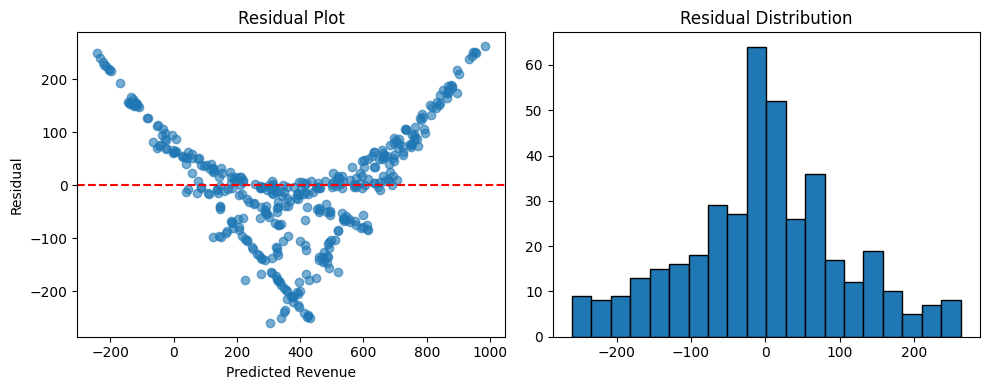

Residual summary:
  Mean: -2.12
  Std: 108.70


In [5]:
residuals = y_test.values - y_pred

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Revenue')
plt.ylabel('Residual')
plt.title('Residual Plot')

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=20, edgecolor='black')
plt.title('Residual Distribution')
plt.tight_layout()
plt.show()

print('Residual summary:')
print(f'  Mean: {residuals.mean():.2f}')
print(f'  Std: {residuals.std():.2f}')

In [6]:
model_path = models_dir / 'sales_model.pkl'
joblib.dump(model, model_path)
print(f'Saved model: {model_path.name}')

Saved model: sales_model.pkl


## Interpretation

- **RMSE** gives average prediction error in revenue units.
- **R2** indicates how much variance is explained by the model.
- Residual plots help detect bias and heteroscedasticity.
- This model can support planning for inventory and staffing decisions.